## 1. Наивный байесовский классификатор

Best parameters: {'var_smoothing': 0.01}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



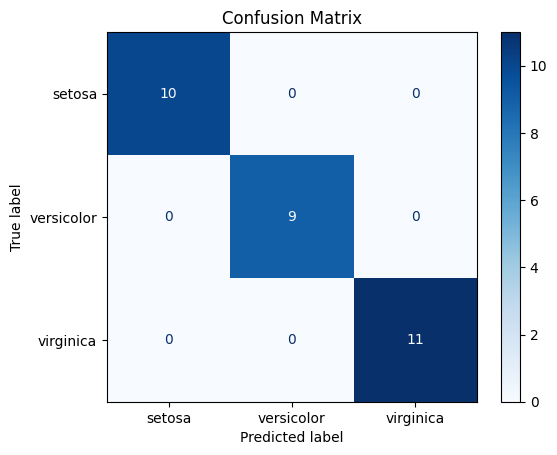

Model saved as naive_bayes_model.pkl


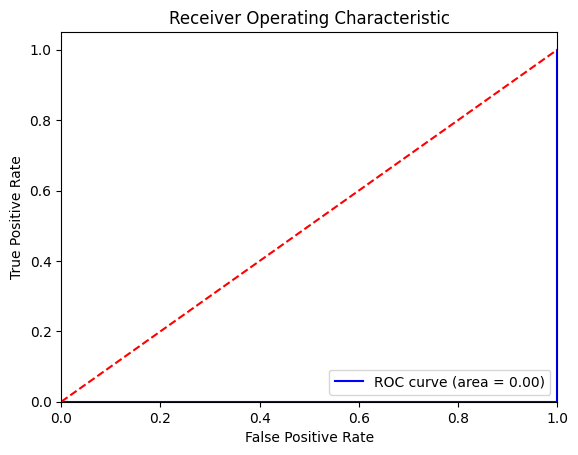

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

data = load_iris()
X = data.data
y = data.target

'''Предобработка данных'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

'''Разделение на обучающую и тестовую выборки'''
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

'''Настройка параметров для GridSearchCV'''
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=10)
}

'''Создание модели и выполнение поиска по сетке'''
gnb = GaussianNB()
grid_search = GridSearchCV(gnb, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

'''Лучшая модель'''
best_model = grid_search.best_estimator_

'''Предсказание'''
y_pred = best_model.predict(X_test)

'''Оценка качества'''
print("Best parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

'''Визуализация матрицы'''
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

'''Сохранение модели'''
joblib.dump(best_model, 'naive_bayes_model.pkl')
print("Model saved as naive_bayes_model.pkl")

'''ROC-кривая (только для бинарной классификации, здесь для примера)'''
'''Преобразуем для двух классов (например, 0 и 1)'''
y_test_binary = (y_test == 0).astype(int)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_prob)
roc_auc = auc(fpr, tpr)

'''Визуализация ROC-кривой'''
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## 2. Деревья решений

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Cross-Validation Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean CV Score: 0.96


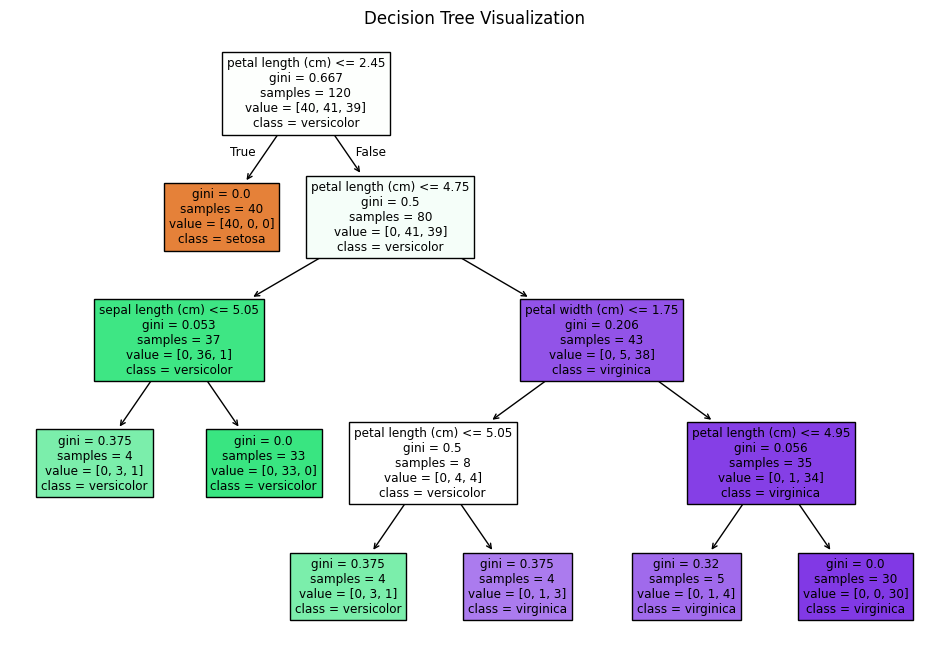

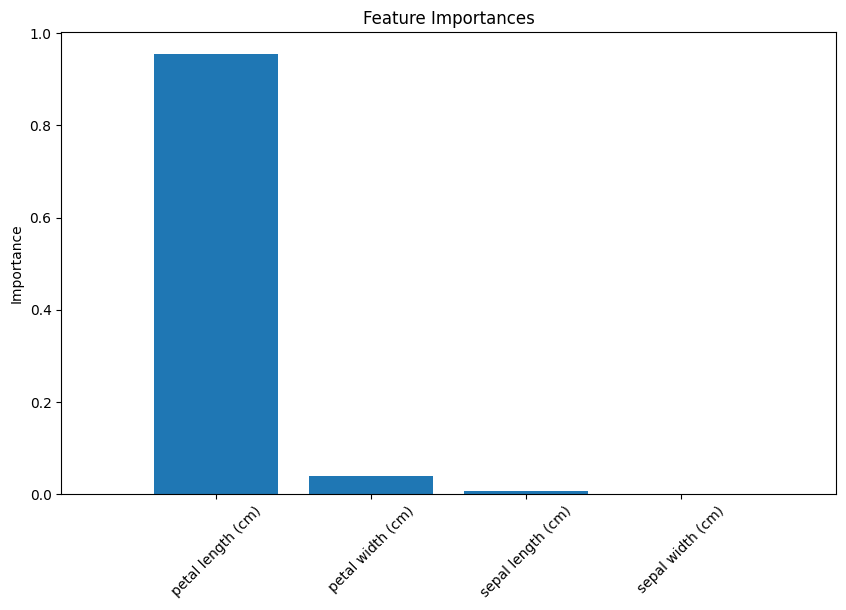

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

'''Загрузка данных'''
data = datasets.load_iris()
X = data.data
y = data.target

'''Разделение на обучающую и тестовую выборки'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Настройка гиперпараметров с помощью Grid Search
param_grid = {
    'max_depth': [None, 2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

'''Оптимальные параметры'''
best_params = grid_search.best_params_
print("Best parameters:", best_params)

'''Обучение модели с лучшими параметрами'''
tree_model = DecisionTreeClassifier(**best_params, random_state=42)
tree_model.fit(X_train, y_train)

'''Предсказание'''
y_pred_tree = tree_model.predict(X_test)

'''Оценка качества'''
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

'''Кросс-валидация'''
cv_scores = cross_val_score(tree_model, X, y, cv=5)
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

'''Визуализация дерева решений'''
plt.figure(figsize=(12, 8))
plot_tree(tree_model, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title('Decision Tree Visualization')
plt.show()

'''Визуализация важности признаков'''
feature_importances = tree_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X.shape[1]), np.array(data.feature_names)[indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel('Importance')
plt.show()

## 3. Метод опорных векторов (SVM)

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Cross-Validation Scores: [1.         1.         0.9        0.96666667 1.        ]
Mean CV Score: 0.9733333333333334


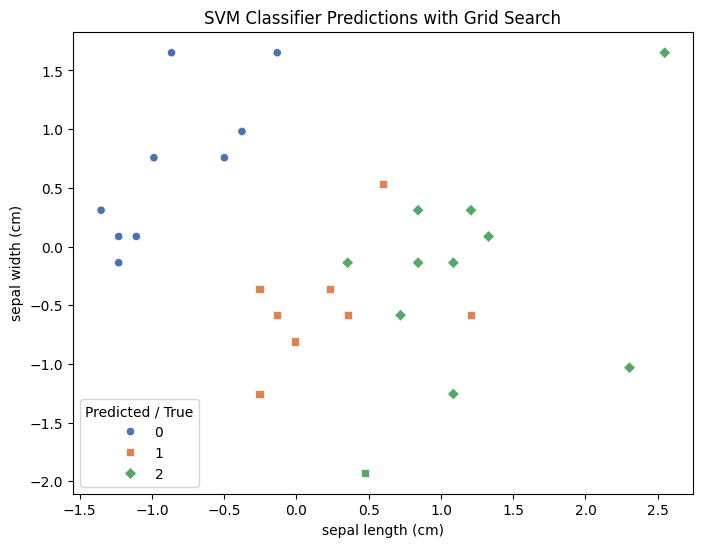

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

'''Загрузка данных'''
data = datasets.load_iris()
X = data.data
y = data.target

'''Разделение на обучающую и тестовую выборки'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''Cтандартизация данных'''
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''Настройка гиперпараметров с помощью Grid Search'''
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

'''Оптимальные параметры'''
best_params = grid_search.best_params_
print("Best parameters:", best_params)

'''Обучение модели с лучшими параметрами'''
svm_model = SVC(**best_params, random_state=42)
svm_model.fit(X_train, y_train)

'''Предсказание'''
y_pred_svm = svm_model.predict(X_test)

'''Оценка качества'''
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

'''Кросс-валидация'''
cv_scores = cross_val_score(svm_model, X, y, cv=5)
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

'''Визуализация'''
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_svm, palette='deep', style=y_test, markers=["o", "s", "D"])
plt.title('SVM Classifier Predictions with Grid Search')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend(title='Predicted / True')
plt.show()

## 4. k-ближайших соседей (k-NN)

Best parameters: {'n_neighbors': 9, 'weights': 'distance'}
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Cross-Validation Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean CV Score: 0.9733333333333334


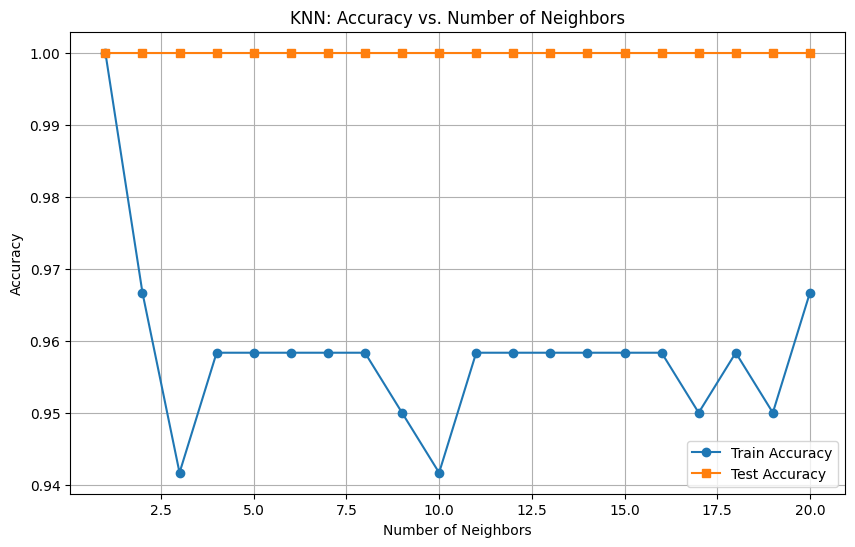

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

'''Загрузка данных'''
data = datasets.load_iris()
X = data.data
y = data.target

'''Разделение на обучающую и тестовую выборки'''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''Стандартизация данных'''
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

'''Настройка гиперпараметров с помощью Grid Search'''
param_grid = {
    'n_neighbors': np.arange(1, 21),
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

'''Оптимальные параметры'''
best_params = grid_search.best_params_
print("Best parameters:", best_params)

'''Обучение модели с лучшими параметрами'''
knn_model = KNeighborsClassifier(**best_params)
knn_model.fit(X_train, y_train)

'''Предсказание'''
y_pred_knn = knn_model.predict(X_test)

'''Оценка качества'''
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

'''Кросс-валидация'''
cv_scores = cross_val_score(knn_model, X, y, cv=5)
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

'''Визуализация влияния n_neighbors на точность'''
neighbors = np.arange(1, 21)
train_accuracy = []
test_accuracy = []

for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracy, label='Train Accuracy', marker='o')
plt.plot(neighbors, test_accuracy, label='Test Accuracy', marker='s')
plt.title('KNN: Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Кластеризация
## 1. K-Means

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
'''Генерация данных'''
X_blob, y_blob = make_blobs(n_samples=300, centers=4, random_state=42)

In [ ]:
'''Стандартизация данных'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_blob)
X_scaled

array([[-1.11618972e+00,  5.83771789e-01],
       [-1.19214185e+00,  6.58632948e-01],
       [ 3.25203835e-01,  7.96110991e-01],
       [-6.99477202e-01, -1.38795911e+00],
       [-1.41517920e+00,  5.58311957e-01],
       [-4.95826957e-01, -1.59047610e+00],
       [ 1.55613267e+00, -7.83287999e-02],
       [-5.80050487e-01, -1.65544196e+00],
       [ 7.86816008e-02,  9.62663722e-01],
       [ 1.29772382e+00, -3.46891133e-02],
       [ 5.54761692e-02,  1.29055111e+00],
       [ 1.59094764e+00, -2.51806685e-01],
       [ 2.08983612e-01,  6.77239865e-01],
       [-9.86172076e-02,  9.24856345e-01],
       [-1.15241503e+00,  6.42130301e-01],
       [ 3.64723473e-02,  9.39816576e-01],
       [-1.33742232e+00,  7.28241258e-01],
       [ 1.13980967e+00, -1.10324238e-01],
       [ 1.87813343e-01,  1.14838177e+00],
       [ 2.80568794e-01,  1.34496109e+00],
       [ 1.74275252e+00, -2.72364269e-01],
       [ 1.38883980e-01,  1.05754320e+00],
       [-4.73582122e-01, -1.58840363e+00],
       [-1.

In [ ]:
'''Определение оптимального количества кластеров с помощью метода локтя'''
inertia = []
k_range = range(1, 11)

In [ ]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

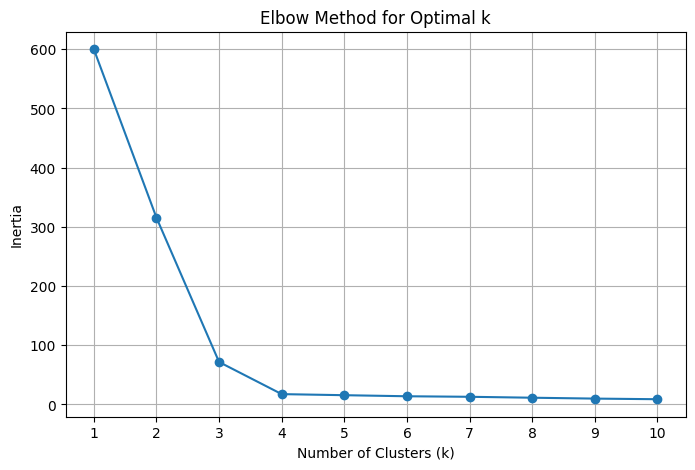

In [ ]:
'''Визуализация метода локтя'''
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid()
plt.show()

In [ ]:
'''Обучение модели с оптимальным количеством кластеров (например, 4)'''
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)
kmeans

KMeans(n_clusters=4, random_state=42)

In [ ]:
'''Предсказание кластеров'''
y_kmeans = kmeans.predict(X_scaled)
y_kmeans

array([3, 3, 0, 1, 3, 1, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 3, 2, 0, 0, 2, 0,
       1, 3, 0, 3, 3, 1, 1, 2, 0, 2, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       0, 0, 3, 2, 3, 2, 1, 3, 1, 0, 1, 2, 3, 2, 2, 0, 3, 2, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 1, 1, 0, 1, 0, 0, 3, 0, 1, 3, 3, 2,
       2, 2, 3, 0, 3, 0, 0, 3, 1, 0, 3, 3, 2, 2, 2, 0, 0, 0, 0, 0, 1, 3,
       2, 0, 0, 0, 0, 2, 3, 1, 3, 1, 1, 1, 0, 3, 1, 3, 3, 0, 3, 1, 2, 0,
       0, 0, 0, 2, 2, 3, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 3, 2, 1,
       0, 2, 1, 3, 3, 2, 0, 3, 1, 3, 2, 3, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 3, 0, 3, 2, 2, 3, 1, 0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2,
       2, 3, 0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 0, 1, 1, 2, 3, 1, 3, 3, 0, 3,
       3, 1, 3, 1, 2, 2, 3, 3, 2, 2, 2, 3, 0, 1, 2, 1, 3, 2, 3, 3, 3, 1,
       1, 2, 3, 1, 1, 1, 3, 1, 3, 1, 3, 2, 1, 3, 2, 0, 3, 0, 2, 0, 3, 0,
       1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 1, 0, 0, 2, 2, 2, 2, 1, 3, 2,
       1, 2, 2, 1, 0, 1, 2, 0, 3, 0, 2, 0, 3, 3], d

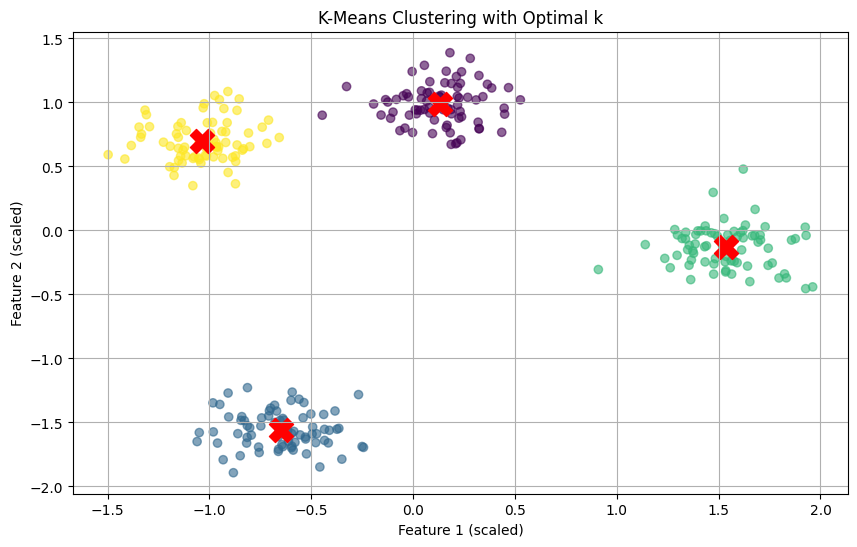

In [ ]:
'''Визуализация кластеров'''
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', marker='o', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title('K-Means Clustering with Optimal k')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.grid()
plt.show()

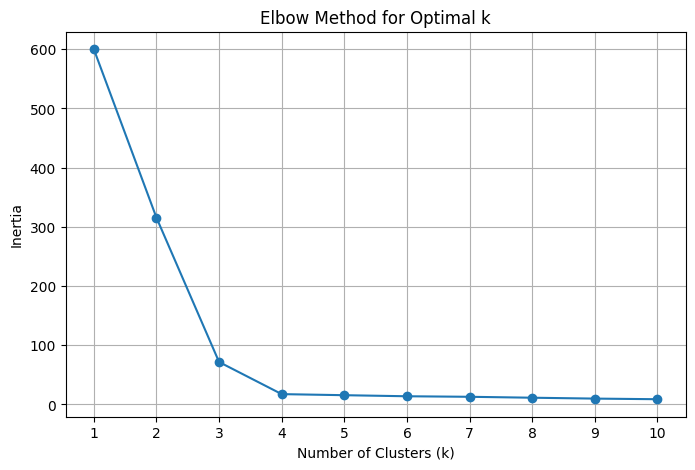

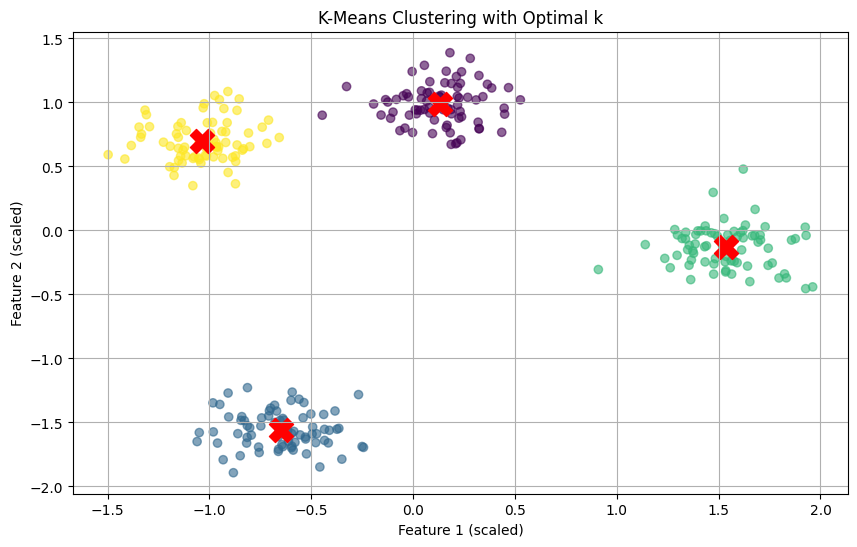

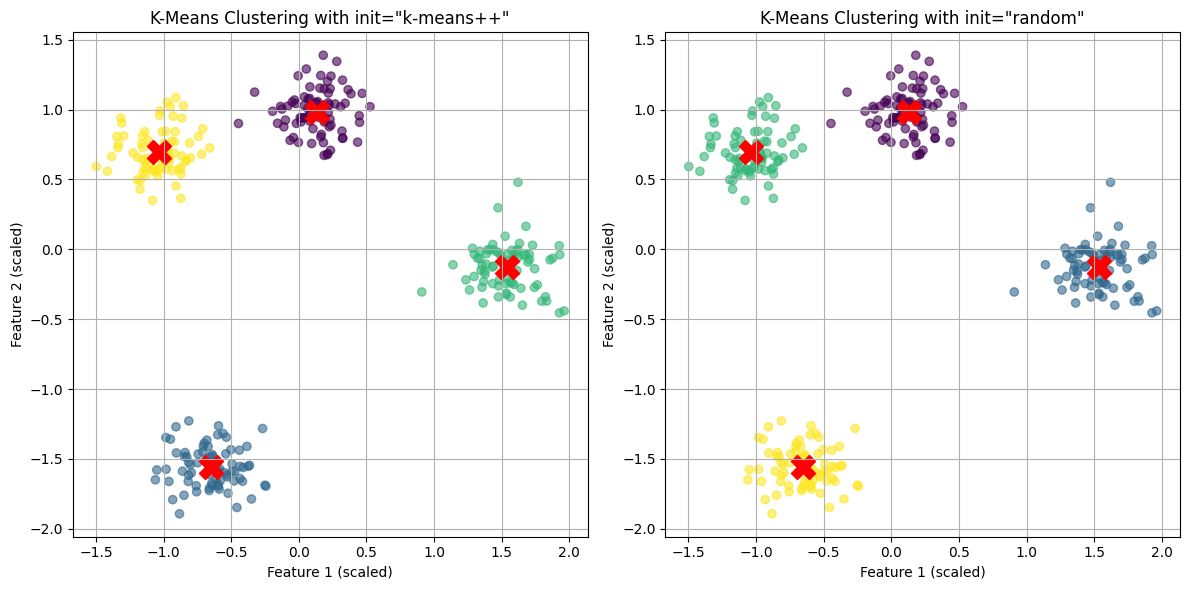

In [ ]:
'''Сравнение различных инициализаций'''
init_methods = ['k-means++', 'random']
plt.figure(figsize=(12, 6))

for i, init in enumerate(init_methods, 1):
    kmeans = KMeans(n_clusters=optimal_k, init=init, random_state=42)
    y_kmeans = kmeans.fit_predict(X_scaled)
    plt.subplot(1, 2, i)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', marker='o', alpha=0.6)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
    plt.title(f'K-Means Clustering with init="{init}"')
    plt.xlabel('Feature 1 (scaled)')
    plt.ylabel('Feature 2 (scaled)')
    plt.grid()

plt.tight_layout()
plt.show()

---------------------------------------------------------------

### Дополнительные сведения

Кластеризация — это одна из ключевых техник машинного обучения, используемая для группировки объектов на основе схожести их характеристик. Существуют различные подходы к кластеризации, включая как классические алгоритмы, так и более продвинутые методы, которые предлагают улучшенные результаты в зависимости от специфики задачи. Вот некоторые из наиболее интересных и эффективных методов кластеризации:

### 1. **Метод k-средних (k-means clustering)**
   - Один из самых популярных и простых методов кластеризации.
   - Алгоритм разбивает данные на *k* кластеров, минимизируя сумму квадратов расстояний точек до центров кластеров.
   - Плюсы: быстрый, простой в реализации.
   - Минусы: требует задания количества кластеров заранее (*k*), чувствителен к выбору начальных центров кластеров.

### 2. **Иерархическая кластеризация (Hierarchical Clustering)**
   - Этот метод строится на двух подходах: агломеративной (снизу вверх) и дивизивной (сверху вниз).
   - Агломеративная иерархическая кластеризация начинается с каждого элемента как отдельного кластера и постепенно объединяет похожие объекты.
   - Дивизивная иерархическая кластеризация работает наоборот: она начинает с одного большого кластера и последовательно делит его на меньшие группы.
   - Плюсы: не нужно заранее указывать количество кластеров, создает дерево связей (дендрограмму), которое показывает структуру данных.
   - Минусы: медленнее по сравнению с методом k-средних, результат зависит от выбора меры расстояния.

### 3. **EM-кластеризация (Expectation Maximization, EM algorithm)**
   - Метод EM основан на вероятностной модели и используется для нахождения скрытых переменных в наборе данных.
   - Применяется для мягкого (мягкой кластеризации), где каждому объекту присваивается вероятность принадлежности к разным кластерам.
   - Плюсы: учитывает неопределенность, подходит для сложных данных.
   - Минусы: чувствителен к начальной инициализации, может потребовать больше вычислительных ресурсов.

### 4. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
   - DBSCAN — алгоритм плотностной кластеризации, который находит кластеры, основываясь на плотности точек в пространстве.
   - Кластерами считаются области высокой плотности, окруженные областями низкой плотности (шумом).
   - Плюсы: обнаружение кластеров произвольной формы, игнорирование шума.
   - Минусы: чувствительность к параметрам (minPts и ε), плохо работает на неравномерных данных.

### 5. **Spectral Clustering (Спектральная кластеризация)**
   - Спектральный подход к кластеризации базируется на анализе спектра матрицы смежности (графа, представляющего связи между объектами).
   - Идеально подходит для данных, которые имеют сложную внутреннюю структуру.
   - Плюсы: высокая точность для нелинейных данных, устойчивость к шуму.
   - Минусы: относительно сложный алгоритм, требующий преобразования данных.

### 6. **Self-Organizing Maps (SOM, карты Кохонена)**
   - Нейронная сеть, использующая конкурентное обучение для создания двумерной карты признаков многомерных данных.
   - Каждый узел сети представляет отдельный кластер, который соответствует группе похожих входных векторов.
   - Плюсы: визуализирует многомерные данные в виде двумерной карты, сохраняет топологию данных.
   - Минусы: требует настройки многих гиперпараметров, чувствительна к порядку подачи данных.

### 7. **Gaussian Mixture Models (GMM)**
   - Вероятностная модель, которая предполагает, что данные генерируются смесью гауссовых распределений.
   - Подходит для мягких кластеров, где каждый объект может принадлежать одновременно нескольким кластерам с разной вероятностью.
   - Плюсы: гибкая модель, учитывающая статистические свойства данных.
   - Минусы: сложность оценки параметров, может требовать значительных вычислительных ресурсов.

### 8. **Agglomerative Information Bottleneck (AIB)**
   - Алгоритм AIB использует теорию информации для объединения объектов в кластеры, минимизируя потерю информации при сжатии данных.
   - Эффективен для обработки больших объемов данных.
   - Плюсы: теоретически обоснованный подход, устойчивость к шуму.
   - Минусы: высокие требования к вычислительным ресурсам.

### 9. **Deep Learning-based Clustering**
   - Современные подходы используют глубокие нейронные сети для извлечения представлений данных и последующего кластерного анализа.
   - Примером является **Autoencoders** + K-means, где автоэнкодер сжимает данные, а затем применяется кластеризация.
   - Плюсы: способность справляться с высокими размерностями, эффективность для сложных задач.
   - Минусы: сложная настройка моделей, требовательность к большим объемам данных.

### 10. **Consensus Clustering (Консенсусная кластеризация)**
   - Консенсусный подход объединяет результаты множества различных кластеризационных решений для получения более стабильного результата.
   - Используется для повышения надежности и уменьшения влияния случайных факторов.
   - Плюсы: повышает надежность и стабильность результатов.
   - Минусы: увеличение времени вычислений.

---

### Когда использовать эти методы?

- **k-means**: подходит для простых задач с однородными кластерами.
- **Иерархическая кластеризация**: полезна для выявления структуры данных и визуальной интерпретации отношений между объектами.
- **EM-кластеризация**: хороша для вероятностных данных и мягких кластеров.
- **DBSCAN**: идеален для обнаружения кластеров сложной формы и наличия шума.
- **Spectral Clustering**: эффективен для нелинейных и сложных данных.
- **SOM**: полезен для визуального исследования и картографирования многомерных данных.
- **GMM**: подходит для смешанных распределений и мягких кластеров.
- **AIB**: оптимален для больших объемов данных.
- **Deep Learning-based Clustering**: необходим для сложных задач и высокоразмерных данных.
- **Consensus Clustering**: используется для повышения стабильности и надежности результатов.

Выбор метода зависит от природы ваших данных, целей анализа и требований к производительности.

----------------------------------------------------------------

1. K-Means Clustering

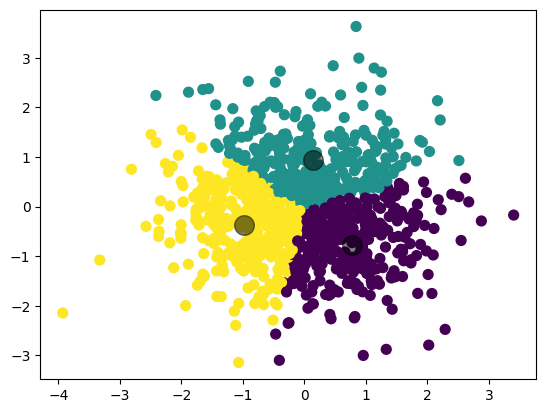

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
X = np.random.randn(1000, 2)

# Создание модели KMeans с 3 кластерами
model = KMeans(n_clusters=3, random_state=42)

# Обучение модели
model.fit(X)

# Прогнозирование кластеров для каждой точки
labels = model.predict(X)

# Центры кластеров
centers = model.cluster_centers_

# Визуализация результатов
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
plt.show()

2. Иерархическая кластеризация (Agglomerative Clustering)

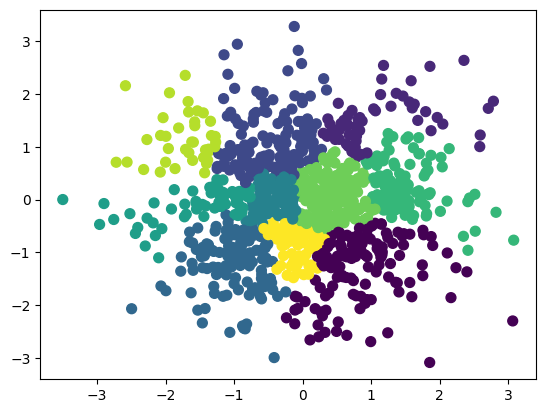

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
X = np.random.randn(1000, 2)

# Создание модели иерархической кластеризации с 3 кластерами
model = AgglomerativeClustering(n_clusters=10)

# Обучение модели
model.fit(X)

# Прогнозирование кластеров для каждой точки
labels = model.labels_

# Визуализация результатов
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');
plt.show()

3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

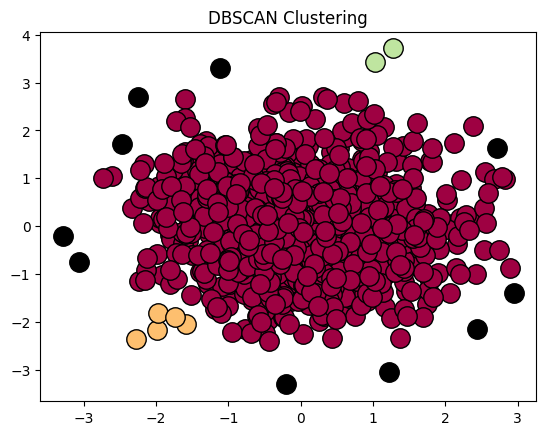

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
X = np.random.randn(1000, 2)

# Создание модели DBSCAN
model = DBSCAN(eps=0.5, min_samples=2)

# Обучение модели
model.fit(X)

# Прогнозирование кластеров для каждой точки
labels = model.labels_

# Визуализация результатов
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Черный цвет для шума
        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

plt.title('DBSCAN Clustering')
plt.show()

4. Spectral Clustering

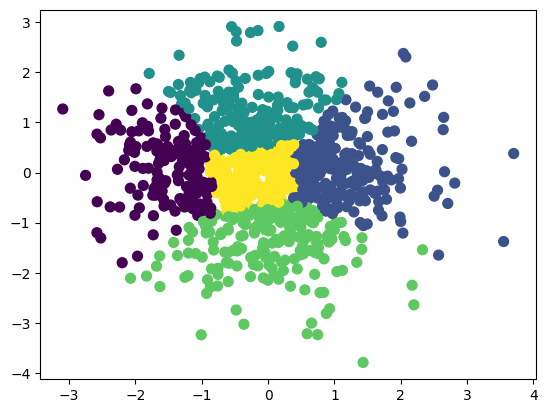

In [ ]:
from sklearn.cluster import SpectralClustering
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
X = np.random.randn(1000, 2)

# Создание модели спектральной кластеризации с 3 кластерами
model = SpectralClustering(n_clusters=5, affinity='nearest_neighbors')

# Обучение модели
model.fit(X)

# Прогнозирование кластеров для каждой точки
labels = model.labels_

# Визуализация результатов
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');
plt.show()

5. Gaussian Mixture Model (GMM)

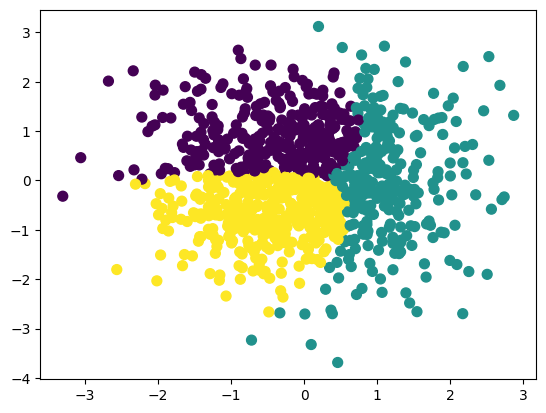

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
X = np.random.randn(1000, 2)

# Создание модели GMM с 3 компонентами
model = GaussianMixture(n_components=3, covariance_type='full')

# Обучение модели
model.fit(X)

# Прогнозирование кластеров для каждой точки
labels = model.predict(X)

# Визуализация результатов
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');
plt.show()

6. Self-Organizing Map (SOM)

Для Self-Organizing Maps можно использовать библиотеку MiniSom:

In [ ]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=5e83830e1b1fb54a7e6a6541bf40c997985cc5a6768e421f2f8b9dc19d15c7a6
  Stored in directory: /root/.cache/pip/wheels/19/db/95/5e53bc2b88a328217fdf9f2886cafbe86b0df274f4b601f572
Successfully built minisom


In [ ]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетического набора данных
data = np.random.rand(1000, 2)

# Создание модели SOM размера 10x10
som = MiniSom(10, 10, data.shape[1], sigma=1.0, learning_rate=0.5)

# Обучение модели
som.train_random(data, 50000)

# Получение индексов кластеров для каждой точки
labels = som.winner(data)

# Визуализация результатов
plt.figure(figsize=(10, 10))
plt.pcolormesh(som.distance_map().T)
plt.colorbar()
plt.title('U-matrix')
plt.show()

ValueError: operands could not be broadcast together with shapes (1000,2) (10,10,2) 

7. Consensus Clustering

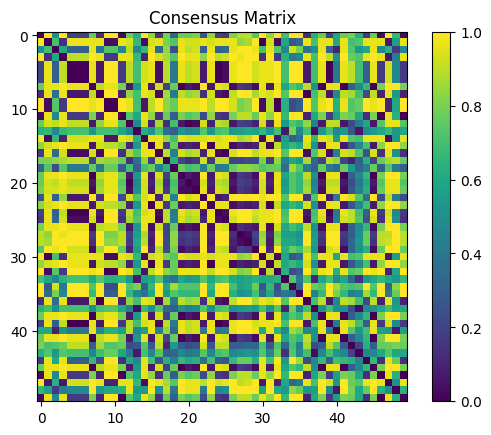

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt

def consensus_clustering(X, n_clusters, n_runs=30):
    labels_list = []

    for _ in range(n_runs):
        model = KMeans(n_clusters=n_clusters, random_state=np.random.randint(1000))
        model.fit(X)
        labels_list.append(model.labels_)

    return labels_list

# Генерация синтетического набора данных
X = np.random.randn(50, 2)

# Применение консенсусной кластеризации
labels_list = consensus_clustering(X, n_clusters=3, n_runs=30)

# Вычисление согласованности между всеми выполнениями
consistency_matrix = np.zeros((len(X), len(X)))
for labels in labels_list:
    consistency_matrix += pairwise_distances(labels.reshape(-1, 1), metric="hamming")

# Нормализация согласованности
consistency_matrix /= len(labels_list)

# Визуализация согласованности
plt.imshow(consistency_matrix, cmap='viridis')
plt.colorbar()
plt.title('Consensus Matrix')
plt.show()

-------------------------------------------------

Как оценить качество моделей?

Оценка качества моделей в машинном обучении является критически важной задачей, которая требует использования различных метрик и методов в зависимости от типа модели и конкретной задачи

. Рассмотрим основные подходы к оценке качества моделей.

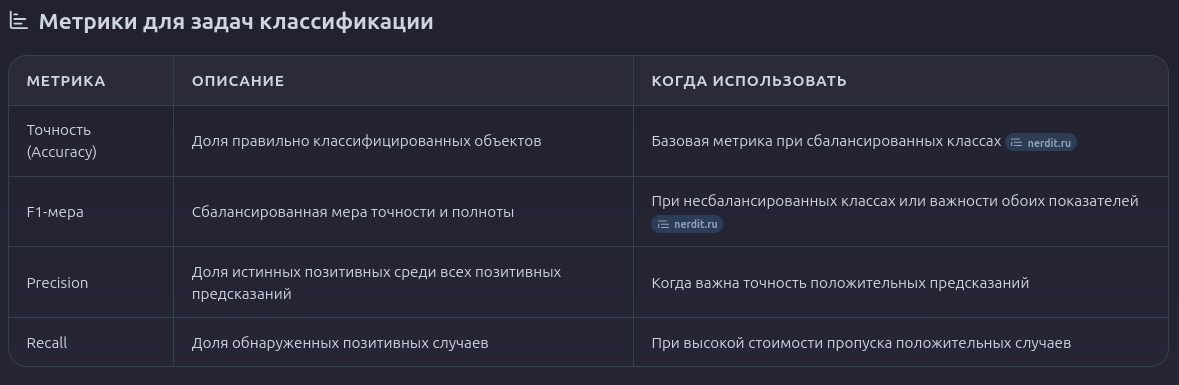

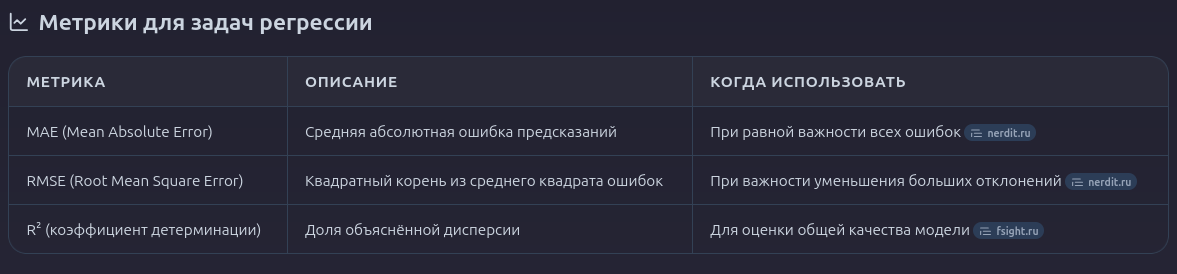

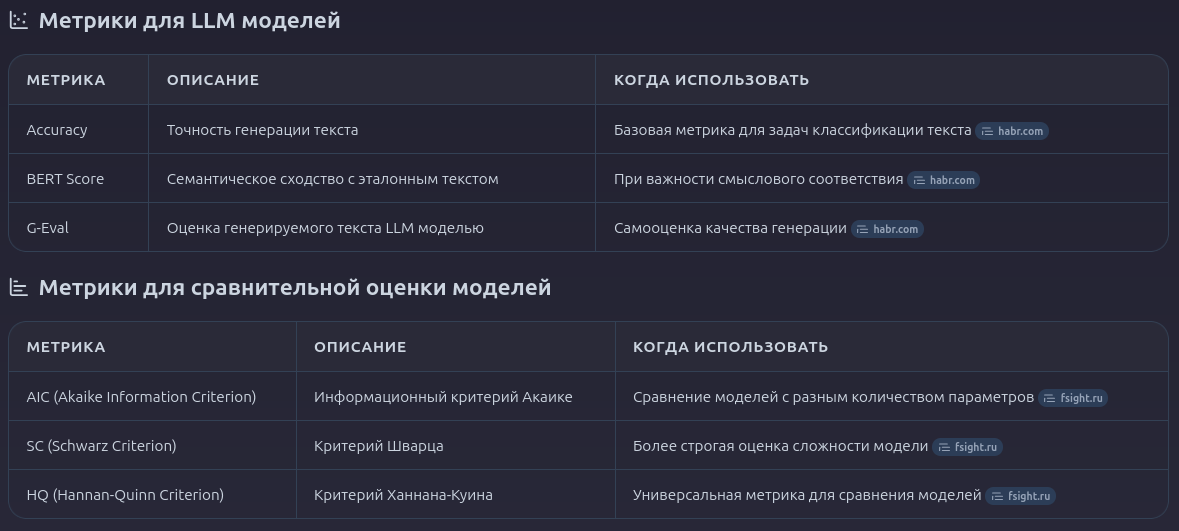

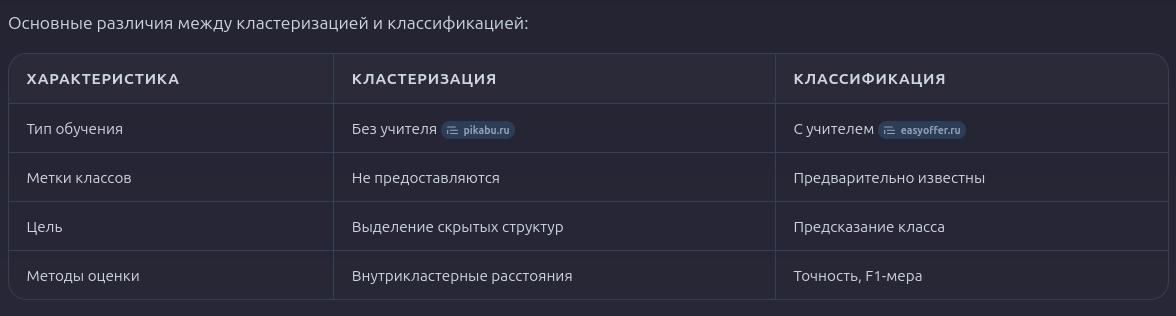